# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## The Lite1 dataset with Performance Tune - within 30 mins (exclude the download time to *.jsonl).

This notebook is an alternative to `day2.ipynb` that creates a smaller dataset for Home Appliances only, to keep training fast and costs low. You may need to update names of future notebooks to reflect that you have built the "lite" dataset not the full dataset.

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
from items import Item
from loaders import ItemLoader
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

# Concurrent load dataset with 4 simultaneously 
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [5]:
dataset_names = [
    "Automotive",    
    "Office_Products",
    "Toys_and_Games", 
    "Tools_and_Home_Improvement",     
    "Software",
    "Electronics",    
    "Health_and_Personal_Care",
    "Cell_Phones_and_Accessories",    
    "Appliances",
    "Musical_Instruments",
]

In [6]:
# Enhanced version to keep the datasets and chucks into disk
# items = []
# for dataset_name in dataset_names:
#     loader = ItemLoader(dataset_name)
#     items.extend(loader.load(6))

# Further performance fine tune ...
# import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

MAX_WORKERS = 6  # Load 6 datasets at a time

def load_dataset_items(name: str):
    try:
        loader = ItemLoader(name, show_progress=False)
        return loader.load(workers=1) # 避免 ThreadPoolExecutor 和 multiprocessing 混用時常見的錯誤
    except Exception as e:
        print(f"❌ Error loading {name}: {e}")
        return []

items = []

# ✅ Run safely with error handling
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(load_dataset_items, name): name for name in dataset_names}
    for future in as_completed(futures):
        try:
            dataset_items = future.result()
            items.extend(dataset_items)
        except Exception as e:
            print(f"⚠️ Unhandled exception: {e}")

print(f"\n🧮 Total items loaded: {len(items):,}")


🔍 Loading dataset: Automotive
✅ Loading from cache: cache\Automotive_dataset
🔍 Loading dataset: Office_Products
✅ Loading from cache: cache\Office_Products_dataset
🔍 Loading dataset: Toys_and_Games
🔍 Loading dataset: Tools_and_Home_Improvement
✅ Loading from cache: cache\Toys_and_Games_dataset
✅ Loading from cache: cache\Tools_and_Home_Improvement_dataset
🔍 Loading dataset: Software
🔍 Loading dataset: Electronics
✅ Loading from cache: cache\Software_dataset
✅ Loading from cache: cache\Electronics_dataset
✅ Completed Software with 14,635 datapoints in 0.7 mins
🔍 Loading dataset: Health_and_Personal_Care
✅ Loading from cache: cache\Health_and_Personal_Care_dataset
✅ Completed Health_and_Personal_Care with 4,591 datapoints in 0.2 mins
🔍 Loading dataset: Cell_Phones_and_Accessories
✅ Loading from cache: cache\Cell_Phones_and_Accessories_dataset
✅ Completed Office_Products with 240,394 datapoints in 1.2 mins
🔍 Loading dataset: Appliances
✅ Loading from cache: cache\Appliances_dataset
✅ Comp

In [7]:
print(f"A grand total of {len(items):,} items")

A grand total of 2,830,634 items


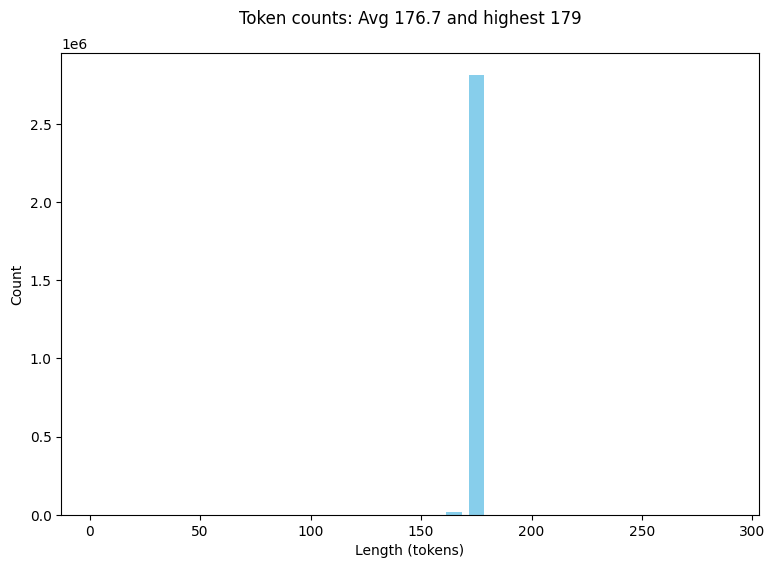

In [8]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

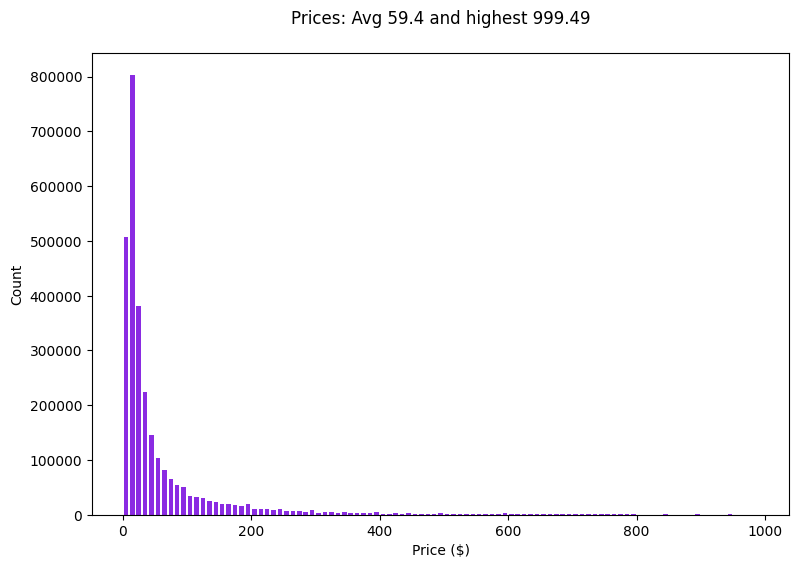

In [9]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

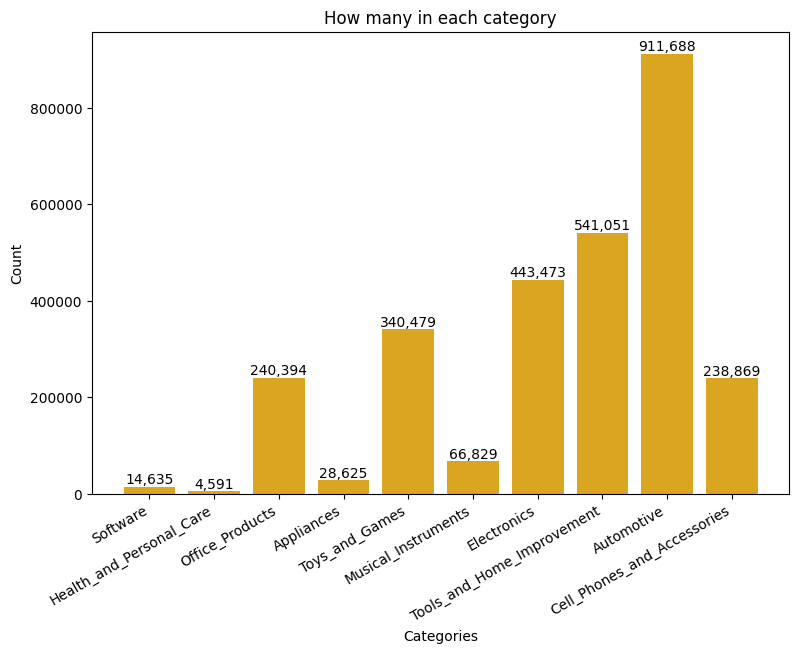

In [10]:
category_counts = Counter()
for item in items:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

# Objective

Craft a dataset which is more balanced in terms of prices. Less heavily scewed to cheap items, with an average that's higher than $60. Try to balance out the categories - fewer Automotive items.

In [11]:
# Create a dict with a key of each price from $1 to $999
# And in the value, put a list of items with that price (to nearest round number)

slots = defaultdict(list)
for item in items:
    slots[round(item.price)].append(item)

In [12]:
# Create a dataset called "sample" which tries to more evenly take from the range of prices
# And gives more weight to items from categories other than Automotive
# Set random seed for reproducibility

np.random.seed(42)
random.seed(42)
sample = []
for i in range(1, 1000):
    slot = slots[i]
    if i>=240:
        sample.extend(slot)
    elif len(slot) <= 1200:
        sample.extend(slot)
    else:

        category_weights = {
            'Automotive': 1
            # 'Musical_Instruments': 6.5,
            # 'Office_Products': 6.25,
            # 'Cell_Phones_and_Accessories': 3.5
        }
        
        weights = np.array([category_weights.get(item.category, 5) for item in slot])        
        # weights = np.array([1 if item.category in ('Musical_Instruments', 'Office_Products') else 6 for item in slot])
        weights = weights / np.sum(weights)
        selected_indices = np.random.choice(len(slot), size=1200, replace=False, p=weights)
        selected = [slot[i] for i in selected_indices]
        sample.extend(selected)

print(f"There are {len(sample):,} items in the sample")

There are 408,814 items in the sample


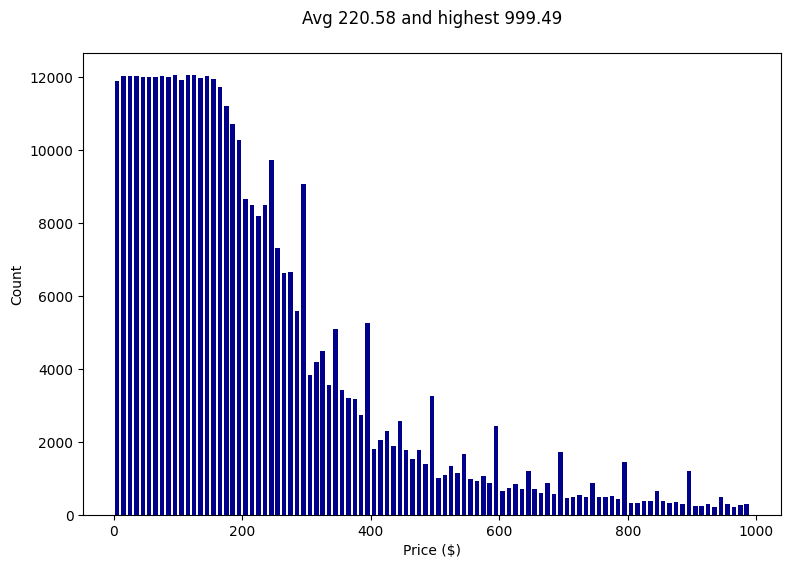

In [13]:
# Plot the distribution of prices in sample

prices = [float(item.price) for item in sample]
plt.figure(figsize=(9, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

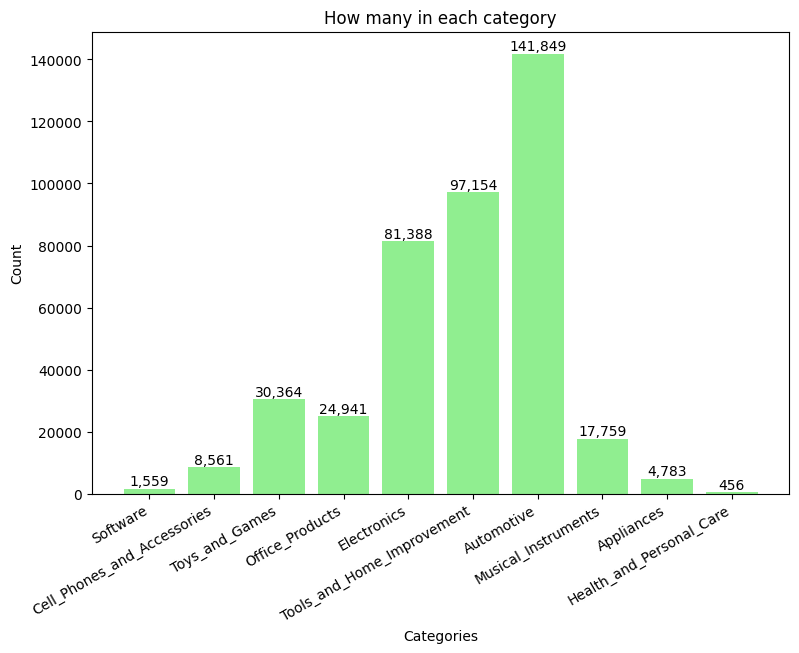

In [14]:
# OK, we did well in terms of raising the average price and having a smooth-ish population of prices
# Let's see the categories

category_counts = Counter()
for item in sample:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Create bar chart
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="lightgreen")

# Customize the chart
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

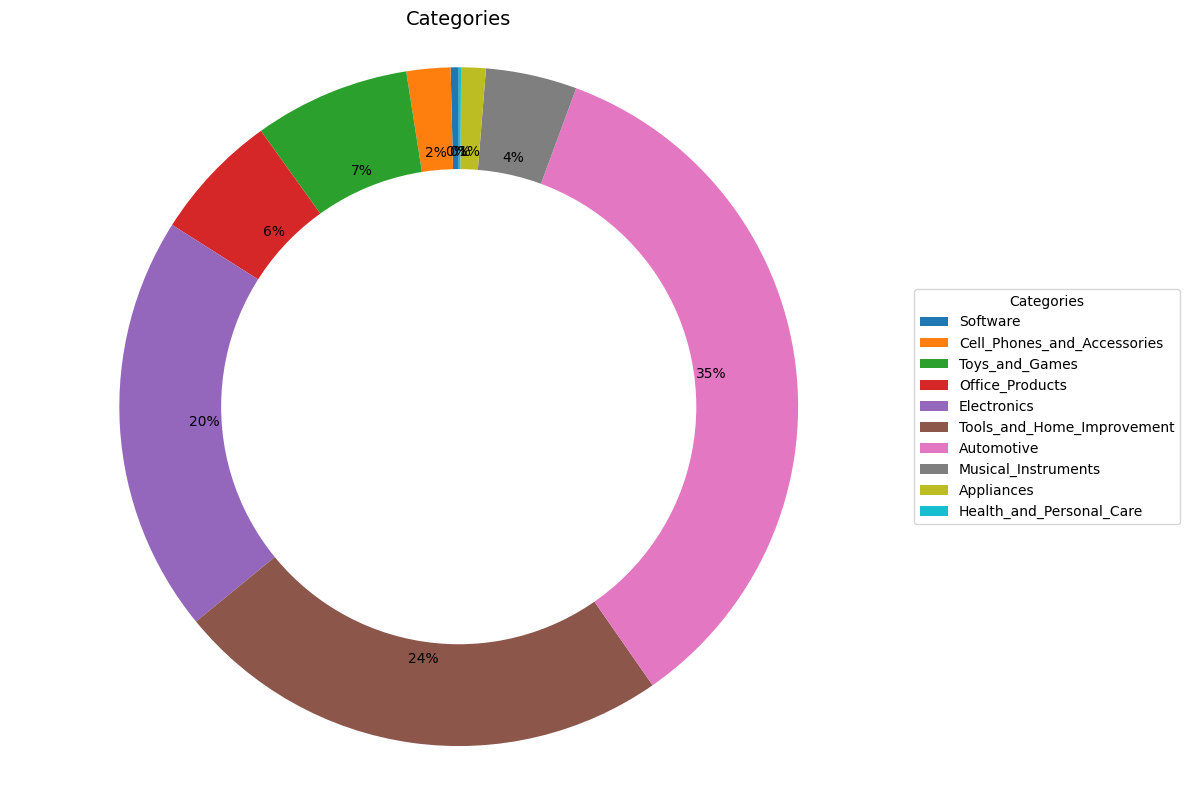

In [15]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 8))

# Draw pie chart with minimal inline labels
wedges, texts, autotexts = plt.pie(
    counts,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)

# Add a circle to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Categories', fontsize=14)

# Add legend to the right
plt.legend(wedges, categories, title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Ensure pie is circular and layout fits
plt.axis('equal')
plt.tight_layout()
plt.show()


# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

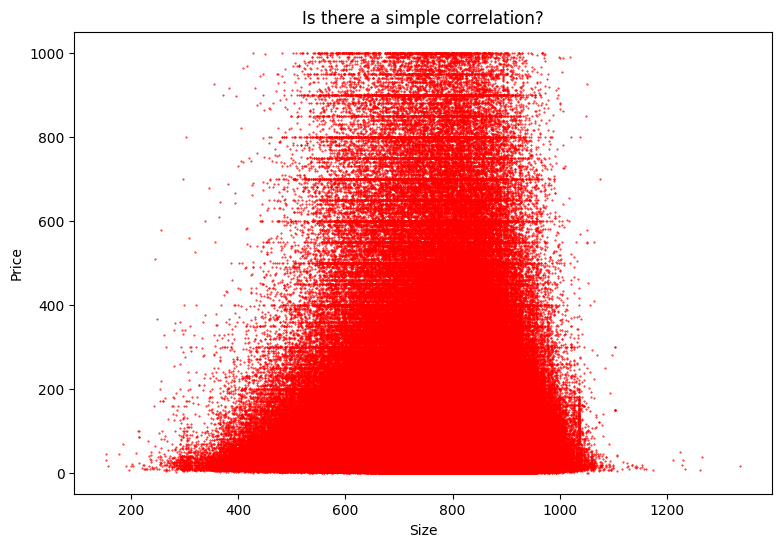

In [16]:
# How does the price vary with the character count of the prompt?

sample = items

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(9, 6))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [17]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(f"Prompt: \n{prompt}")

    last_tokens = tokens[-10:]
    print(f"\nLast 10 tokens: {last_tokens}")
    print(f"Item tokenizer decode last 10 tokens: {Item.tokenizer.batch_decode(last_tokens)}")

In [18]:
report(sample[2000])

Prompt: 
How much does this cost to the nearest dollar?

Village Farmer Simulator 3D
Envy the life of Village Farmer or just want to try harvesting? Now you can be your very own yeoman! The crops are your children--take care of them! You’ll get to drive all the different farm vehicles Plough the seeds in careful order so they are ready later to be harvested. When the season comes, reap your fruit with a harvester! Complete several tasks like this efficiently. Make sure not to miss any, as food is money!About TapinatorTapinator (Ticker TAPM) designs, develops, and publishes games on mobile platforms. The Company’s portfolio includes over 200 mobile gaming titles that, collectively, have achieved over 200 million downloads. Tapinator is headquartered in New York. For more info, visit Tap

Price is $1.00

Last 10 tokens: [11, 4034, 37234, 271, 7117, 374, 400, 16, 13, 410]
Item tokenizer decode last 10 tokens: [',', ' visit', ' Tap', '\n\n', 'Price', ' is', ' $', '1', '.', '00']


In [19]:
report(sample[500000])

Prompt: 
How much does this cost to the nearest dollar?

FORLONG Ceramic Piggy Bank for Boys，Football Coin Bank, Sports Money Box
MATERIAL Made of genuine ceramic and hand painting detail Size 7.5 L x 5 W x 4.4 H There are coin holes on the top and removable rubber plugs under the bottom for easy access Football shape, is the most perfect gift for football fans Not only functional as a great way to save money but also decorative to any sports themed room Dimensions 9.69 x 7.09 x 6.89 inches, Weight 1.3 Pounds, Country of Origin China, model number Manufacturer recommended age 8 years and up, Is Discontinued No, Manufacturer FORLONG, Color Rugby, Material Rubber, Brand FORLONG, Style Rugby

Price is $23.00

Last 10 tokens: [11, 12179, 52002, 271, 7117, 374, 400, 1419, 13, 410]
Item tokenizer decode last 10 tokens: [',', ' Style', ' Rugby', '\n\n', 'Price', ' is', ' $', '23', '.', '00']


## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 25,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [20]:
## Ramdon Sample => takes first 100_000 for training and next 3_000 for testing

random.seed(42)
random.shuffle(sample)
train = sample[:100_000]
test = sample[100_000:103_000]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 100,000 items and test set of 3,000 items


In [21]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

7 Kids Tablet Google Android 4.4 Quad Core Multi-Touch Screen 8GB Hard Drive Pre-Installed Games and Apps, Google Play Store Pink
Standing screen display size 7 Inches, Screen Resolution Max Screen Resolution 1024 x 600, RAM 8 GB Hard Drive 8 GB, Wireless Type Average Battery Life (in hours) 2 Hours, Brand Wopad, Series Touch, model number Hardware Platform Android, Operating System Android 4.4 KitKat, Weight 1.6 ounces, Dimensions 9 x 7 x 4 inches, Color Pink, Rear Webcam Resolution 3 MP, Processor Brand Rockchip, Processors 4, Computer Memory Type DDR3 SDRAM, Flash Memory Size 8 GB, Power Source Corded Electric, Battery Powered

Price is $67.00


In [22]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

M626 Durun
Attention! Due to the size of the tires, Packages might be SEPARATED in the courier facility and not be DELIVERED on the SAME DAY, even though we do ship them together. All tracking information can be checked on courier's website.Durun Durun M626 is a performance and high performance, all season tire manufactured for passenger vehicles and SUVs. The tread design and all season compound increase the dry, wet and winter weather traction. The wide grooves actively resist hydroplaning by dispersing water and slush. The constant road contact boosts the steering responsiveness and driving stability greatly. The shoulder tread blocks enhance the cornering ability and power. The M626 has great high speed performing ability as it does not deform under the high speed driving pressure.FeaturesAll

Price is $


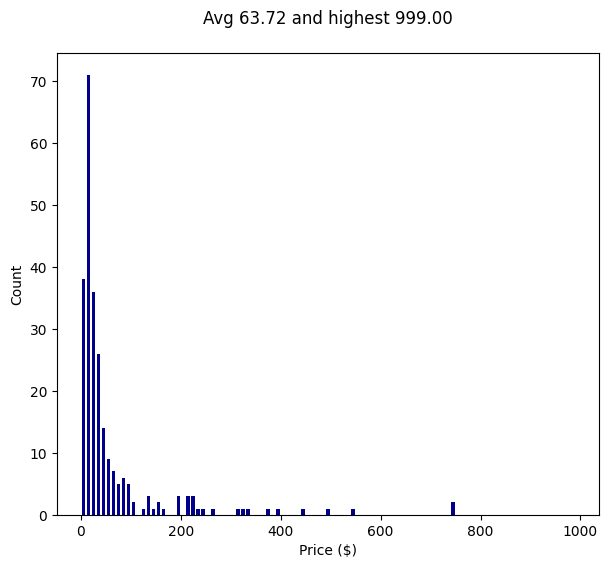

In [23]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(7, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

# Finally - upload your brand new dataset

Convert to prompts and upload to HuggingFace hub

In [24]:
train_prompts = [item.prompt for item in train]
train_prices = [item.price for item in train]
test_prompts = [item.test_prompt() for item in test]
test_prices = [item.price for item in test]

In [25]:
# Create a Dataset from the lists

train_dataset = Dataset.from_dict({"text": train_prompts, "price": train_prices})
test_dataset = Dataset.from_dict({"text": test_prompts, "price": test_prices})
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [26]:
DATASET_NAME = "christseng898/lite-data"
dataset.push_to_hub(DATASET_NAME, private=True)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/100 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/christseng898/lite-data/commit/cf038062cbe5cb5ea1abce9e38a6f9fb8d8260e1', commit_message='Upload dataset', commit_description='', oid='cf038062cbe5cb5ea1abce9e38a6f9fb8d8260e1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/christseng898/lite-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='christseng898/lite-data'), pr_revision=None, pr_num=None)

In [27]:
# One more thing!
# Let's pickle the training and test dataset so we don't have to execute all this code next time!

with open('train_lite.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test_lite.pkl', 'wb') as file:
    pickle.dump(test, file)

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token

In [28]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_prices = ["100", "249", "999"]
tokenized_prices = {price: tokenizer.tokenize(price) for price in sample_prices}
print(tokenized_prices)


{'100': ['100'], '249': ['249'], '999': ['999']}


### Investigate the dataset more!

In [29]:
from datasets import load_dataset, get_dataset_config_names
configs = get_dataset_config_names("McAuley-Lab/Amazon-Reviews-2023")
print(configs)

['raw_meta_All_Beauty', 'raw_meta_Toys_and_Games', 'raw_meta_Cell_Phones_and_Accessories', 'raw_meta_Industrial_and_Scientific', 'raw_meta_Gift_Cards', 'raw_meta_Musical_Instruments', 'raw_meta_Electronics', 'raw_meta_Handmade_Products', 'raw_meta_Arts_Crafts_and_Sewing', 'raw_meta_Baby_Products', 'raw_meta_Health_and_Household', 'raw_meta_Office_Products', 'raw_meta_Digital_Music', 'raw_meta_Grocery_and_Gourmet_Food', 'raw_meta_Sports_and_Outdoors', 'raw_meta_Home_and_Kitchen', 'raw_meta_Subscription_Boxes', 'raw_meta_Tools_and_Home_Improvement', 'raw_meta_Pet_Supplies', 'raw_meta_Video_Games', 'raw_meta_Kindle_Store', 'raw_meta_Clothing_Shoes_and_Jewelry', 'raw_meta_Patio_Lawn_and_Garden', 'raw_meta_Unknown', 'raw_meta_Books', 'raw_meta_Automotive', 'raw_meta_CDs_and_Vinyl', 'raw_meta_Beauty_and_Personal_Care', 'raw_meta_Amazon_Fashion', 'raw_meta_Magazine_Subscriptions', 'raw_meta_Software', 'raw_meta_Health_and_Personal_Care', 'raw_meta_Appliances', 'raw_meta_Movies_and_TV', 'raw_r

In [30]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="5core_timestamp_w_his_Musical_Instruments", split="train")


In [31]:
print(dataset[0])
print(dataset.features)
print(f"Number of Musical Instruments: {len(dataset):,}")

{'user_id': 'AHV6QCNBJNSGLATP56JAWJ3C4G2A', 'parent_asin': 'B00OG187HC', 'rating': '5.0', 'timestamp': '1415286067000', 'history': ''}
{'user_id': Value(dtype='string', id=None), 'parent_asin': Value(dtype='string', id=None), 'rating': Value(dtype='string', id=None), 'timestamp': Value(dtype='string', id=None), 'history': Value(dtype='string', id=None)}
Number of Musical Instruments: 427,957


In [32]:
dataset1 = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="raw_meta_Handmade_Products", split="full", trust_remote_code=True)

In [33]:
print(dataset1[0])
print(dataset1.features)
print(f"Number of Handmade Product: {len(dataset1):,}")

{'main_category': 'Handmade', 'title': 'Daisy Keychain Wristlet Gray Fabric Key fob Lanyard', 'average_rating': 4.5, 'rating_number': 12, 'features': ['High Quality Fabrics', 'Antique Brass Metallic Hardware', '1" wide; Approx. 5-1/2" loop opening', 'Handmade in California'], 'description': ['This charming Daisy Fabric Keychain wristlet features an opening that loops around your wrist allowing your hands to be free to carry other things! This sweet floral daisy key fob will be your little dose of joy, lifting your spirits each time you reach for your keys! PRODUCT DETAILS: Approx. 7" long including the split ring to hold keys. Machine stitched over quality cotton fabric and firm interfacing on inside for structure yet comfortable to hold.'], 'price': 'None', 'images': {'hi_res': [None, None, 'https://m.media-amazon.com/images/I/51TpGYCdKIL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/515dUKmwsbL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/513oIHPmgUL._SL1000_.jpg'], 'lar